# cheaseBS at the campaign box edges

Does reshaping the profiles change how hard cheaseBS has to work?

Four solves per discharge: `Te_ped_scale` and `ne_ped_scale` at the frozen box
edges 0.7 and 1.3. Needs CHEASE, so this runs on NERSC.

**The open question.** The 2026-08-18 five-point 132543 run had four points
converging in 2 iterations and `ne` x1.3 needing 19, with no explanation. These
runs say whether that split follows the direction (up hard, down easy), the
variable (density hard, temperature easy), the discharge, or nothing
reproducible. The answer sets `max_iter` for the campaign, since a cap read off
the typical point truncates the hard one.

`RUN` in the setup cell gates each discharge, so you can solve one, read it, and
turn the next on. Every row carries the `DischargePhysics` for both the scaled
input (`phys_in`, frozen geometry) and the reconstruction (`phys_out`), so the
objects are there to inspect, not just the figures.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pathlib, sys
import matplotlib.pyplot as plt

# Same root-walk the fit and scaling notebooks use, so this runs from any cwd.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pedestal_scan.py").exists())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "reshape_convergence"))

from pedestal_scan import Campaign
import reshape_helpers as rh

# ---- switches -----------------------------------------------------------
# Solve one discharge, read it, then turn the next one on. Each costs four
# cheaseBS solves, so nothing here runs by accident.
RUN = {132543: True, 132588: False, 129015: False, 129038: False}
PLOT = True          # draw the profile + equilibrium comparison after each solve

ROWS = {}            # shot -> rows, filled in by the cells below

camp = Campaign()
print("shots  ", camp.shots)
print("axes   ", rh.AXES)
print("scales ", rh.SCALES)
print("run    ", {k: v for k, v in RUN.items() if v} or "nothing enabled")

[WARNING] TPED.projects.discharge_tools.src.discharge_data: time_ms mismatch: g129015.00409_450→409ms, p129015.00400_x8099→400ms  (files: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129015/g129015.00409_450, /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129015/p129015.00400_x8099)
[WARNING] TPED.projects.discharge_tools.src.discharge_data: time_ms mismatch: g129038.00400→110ms, p129038.00400→400ms  (files: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129038/g129038.00400, /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/129038/p129038.00400)


shots   [129015, 129038, 132543, 132588]
axes    ('Te_ped_scale', 'ne_ped_scale')
scales  (0.7, 1.3)
run     {132543: True}


## Reading the output

**Table.** `dq_max` / `dq_at` / `dq_rms` / `dp_max` are the equilibrium change
over the **whole** profile and the radius where it peaks — cheaseBS reshapes all
of it, so a number read at two radii cannot say whether the reshape reached the
equilibrium. `q_err@x0` is the separate question of whether the campaign's
acceptance gate would take the point, scored at the two GENE analysis radii by
frozen policy (2026-08-16). Keep the two apart.

**Iterations.** Does 1.30 cost more than 0.70? Does `ne` cost more than `Te`?
Does it repeat across discharges?

**`accepted`.** An `R` or a `RAISED` inside the frozen box is a campaign
blocker, not a note.

**`Ip_err`.** Compare +delta against −delta on one axis. A one-sided response is
the open asymmetry.

**Figure.** A reconstruction lying on the black source curve means the reshape
never reached the equilibrium.

In [20]:
def compare(shot, rows, **kwargs):
    """Source against each reconstruction: profiles AND equilibrium, one figure.

    DischargePhysics.plot() draws geometry | T | n plus the gfile panels
    (q, F, p, p', FF'), so a scaling change and the equilibrium change it caused
    are read off the same figure. That is the point of the test: if the T/n
    panels separate but the gfile panels do not, the reshape never reached the
    equilibrium.

    phys_out is the reconstruction reloaded from the run directory -- the scaled
    profiles cheaseBS was handed, plus the EQDSK it produced. phys_in is the
    same profiles on the FROZEN source geometry, so its gfile panels are the
    source by construction; use it to isolate the profile change alone.

    Every object stays on the row, so anything this figure omits is one
    attribute away:

        r = ROWS[132543][0]
        r["phys_out"].ds                   # reconstructed profiles + geometry
        r["phys_out"]._tree["raw/gfile"]   # the reconstructed equilibrium
        r["phys_out"].plot_profiles(rhot=[0.7, 1.0])
        r["phys_out"].plot_gfile(rho_tor=[0.7, 1.0])
        r["phys_out"].plot_geometry()
        r["phys_in"].plot()                # scaled profiles, source geometry
    """
    fig = camp[shot].phys.plot(label="source EFIT", discharge_idx=0, **kwargs)
    for i, r in enumerate(rows, start=1):
        p = r.get("phys_out")
        if p is None:
            continue
        fig = p.plot(fig=fig, discharge_idx=i, **kwargs,
                     label=f"{r['axis'].replace('_ped_scale','')} {r['scale']:.2f}")
    fig.suptitle(f"{shot} — profiles and equilibrium, source vs reconstructions",
                 y=1.01)
    return fig

## 132543

ELMy, low triangularity, and the shot the 2-vs-19 split came from. **Start here.**

132543  radii (0.736, 0.825)  4 solves -> /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260825_09-16-00
  Te_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-16-01-Te_ped_scale_0.700/cheasebs_run_config.json
Starting iterative CHEASE workflow (coordinate=rhop, replay=istar, qspec=on)
Output directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-16-01-Te_ped_scale_0.700
Baseline directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-16-01-Te_ped_scale_0.700/cheasebs_baseline
Run targets: Ip=947061.789 A (source 947061.789 A), Bt=-0.439262 T (source -0.439262 T)
Rebuilding baseline decomposition from reference profiles
Preparing baseline inputs from g132543.00700
Baseline radial mapping complete
Baseline Step 1 complete: thermal/fast pressure split and Zeff
Baseline Step 2 complete: bootstrap/driven current decompositi

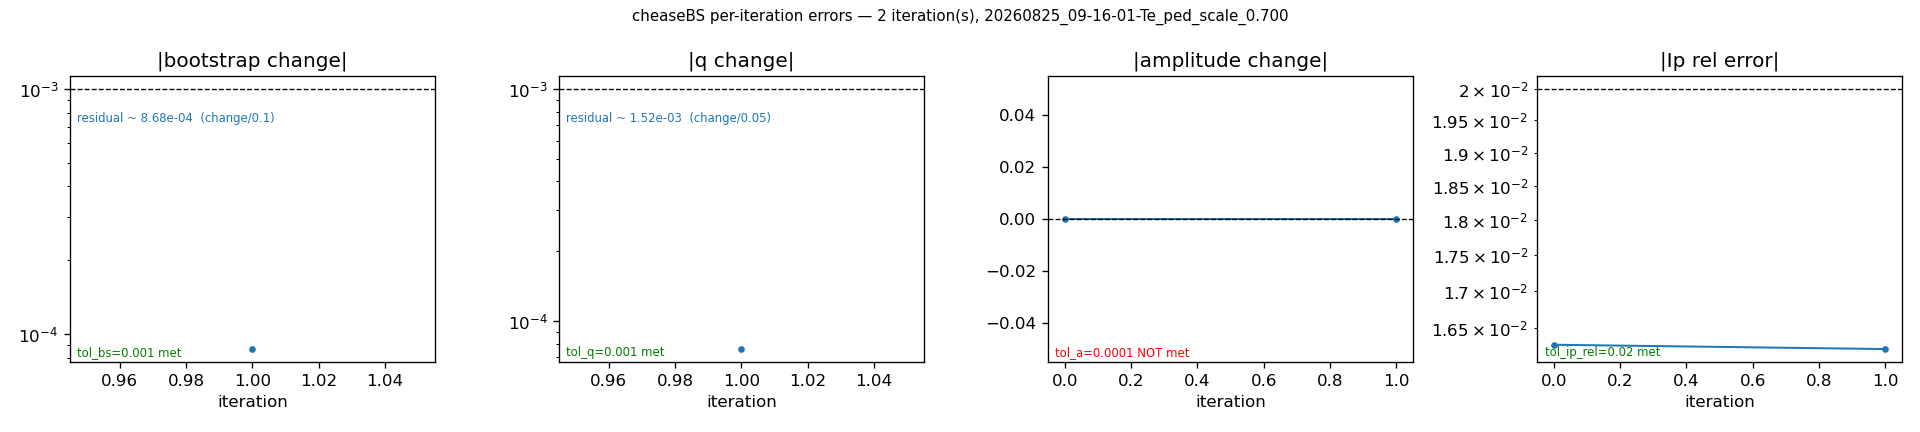

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-16-01-Te_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.622%  (final 931701.6 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.633%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.514%   (deviation from source)
[cheaseBS]   q95 error        0.834%
[cheaseBS]   q edge error    16.913%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-16-01-Te_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260825_09-16-00/Te_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 114s, accepted=True
  Te_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

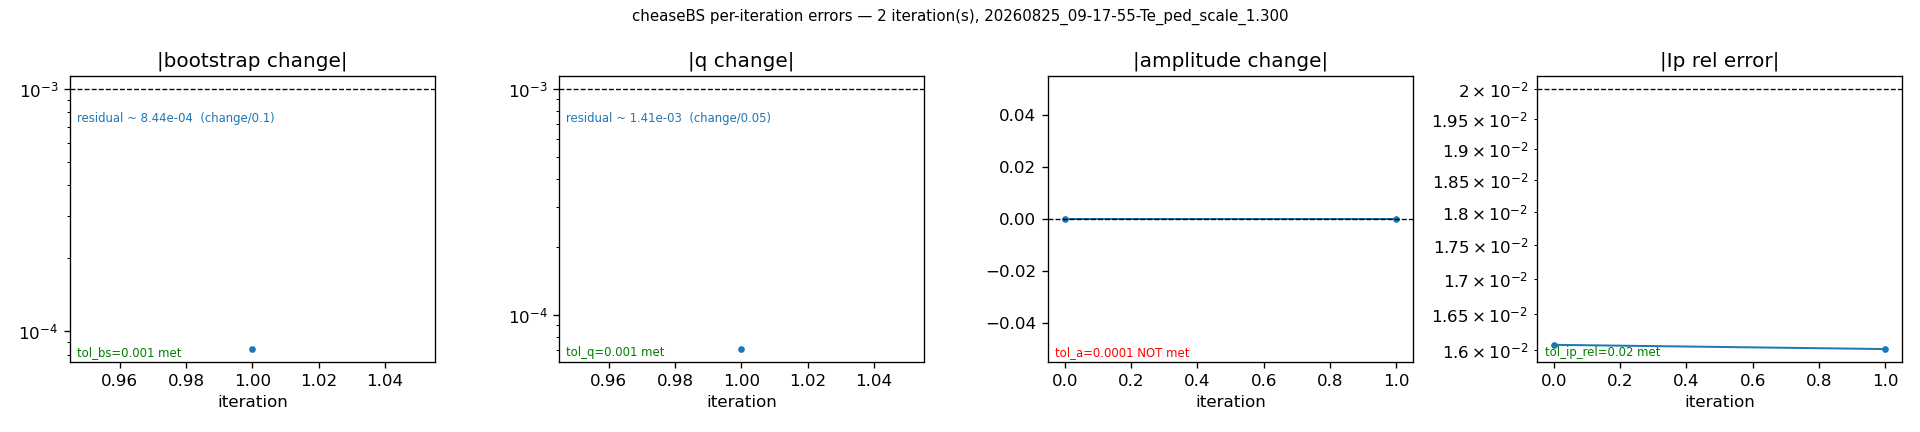

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-17-55-Te_ped_scale_1.300/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.601%  (final 931900.3 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.601%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.287%   (deviation from source)
[cheaseBS]   q95 error        0.874%
[cheaseBS]   q edge error    16.912%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-17-55-Te_ped_scale_1.300
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260825_09-16-00/Te_ped_scale_1.300/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 114s, accepted=True
  ne_ped_scale 0.70 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

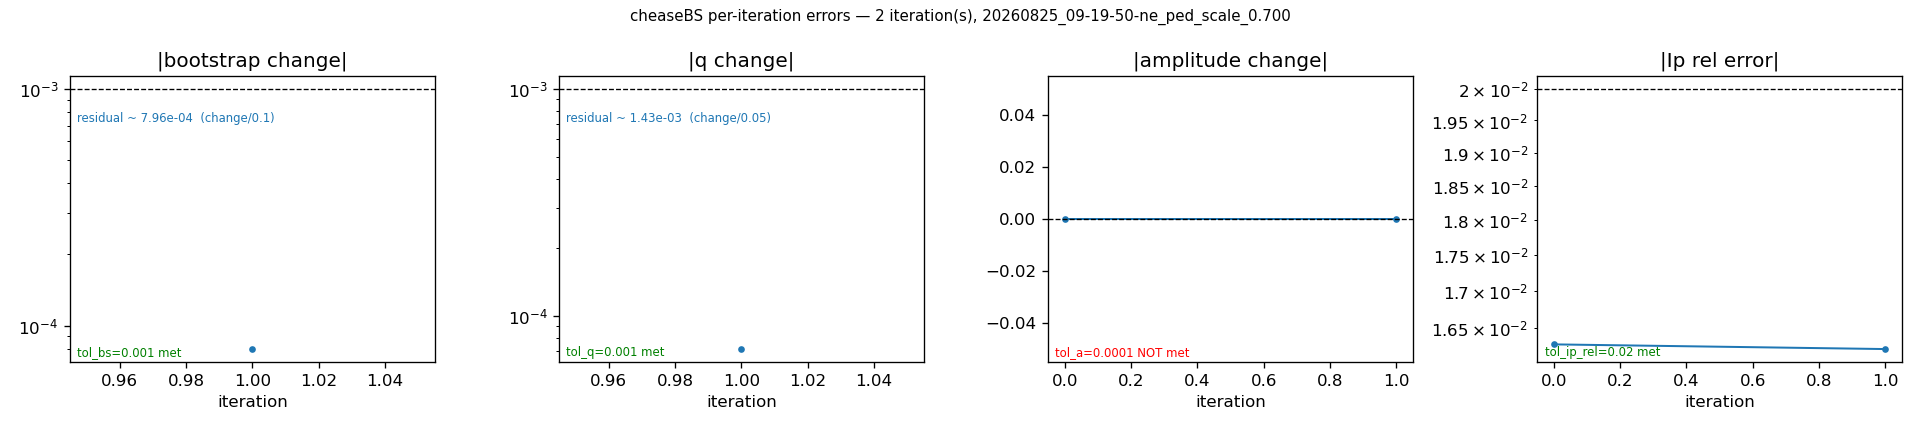

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-19-50-ne_ped_scale_0.700/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.622%  (final 931697.3 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.643%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.515%   (deviation from source)
[cheaseBS]   q95 error        0.834%
[cheaseBS]   q edge error    16.912%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-19-50-ne_ped_scale_0.700
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260825_09-16-00/ne_ped_scale_0.700/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 114s, accepted=True
  ne_ped_scale 1.30 ...[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_

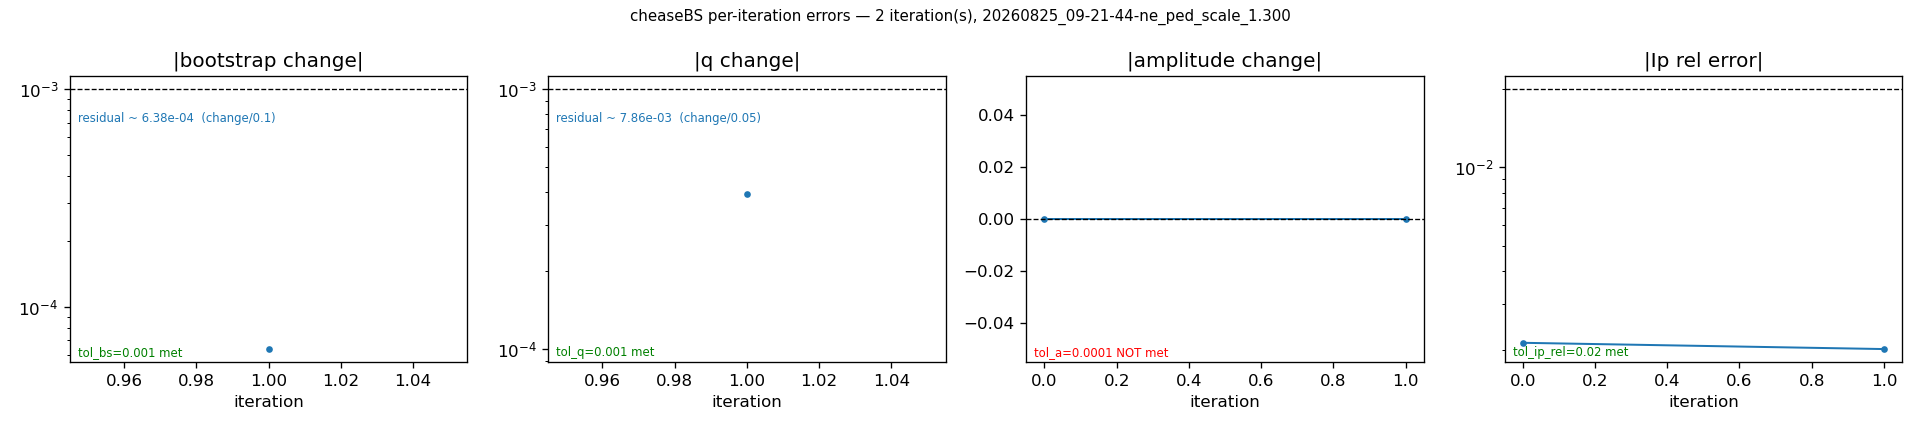

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-21-44-ne_ped_scale_1.300/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         0.201%  (final 945159.1 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   1.701%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   1.360%   (deviation from source)
[cheaseBS]   q95 error        0.666%
[cheaseBS]   q edge error    17.384%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260825_09-21-44-ne_ped_scale_1.300
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/reshape_convergence/runs/132543_20260825_09-16-00/ne_ped_scale_1.300/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
 2 iters, 118s, accepted=True


shot,axis,scale,ped_top,ped_top/nom,iters,converged,accepted,Ip_err,dq_max,dq_at,dq_rms,dp_max,q_err@x0,q_edge_err,wall_s,status
132543,Te_ped_scale,0.700000,2.821e+02,0.913,2,True,True,1.62%,1.29%,0.981,0.50%,2.22%,0.63%,16.91%,114,
132543,Te_ped_scale,1.300000,3.360e+02,1.087,2,True,True,1.60%,1.33%,0.981,0.46%,5.13%,0.60%,16.91%,114,
132543,ne_ped_scale,0.700000,4.071e+19,0.732,2,True,True,1.62%,1.29%,0.981,0.50%,2.23%,0.64%,16.91%,114,
132543,ne_ped_scale,1.300000,7.052e+19,1.268,2,True,True,0.20%,2.70%,0.529,1.52%,25.70%,1.70%,17.38%,118,


In [3]:
if RUN[132543]:
    ROWS[132543], wd = rh.run_bounds(camp, 132543)
    display(rh.table(ROWS[132543], shot=132543))
else:
    print("132543 disabled — set RUN[132543] = True")

displaying results for 132543


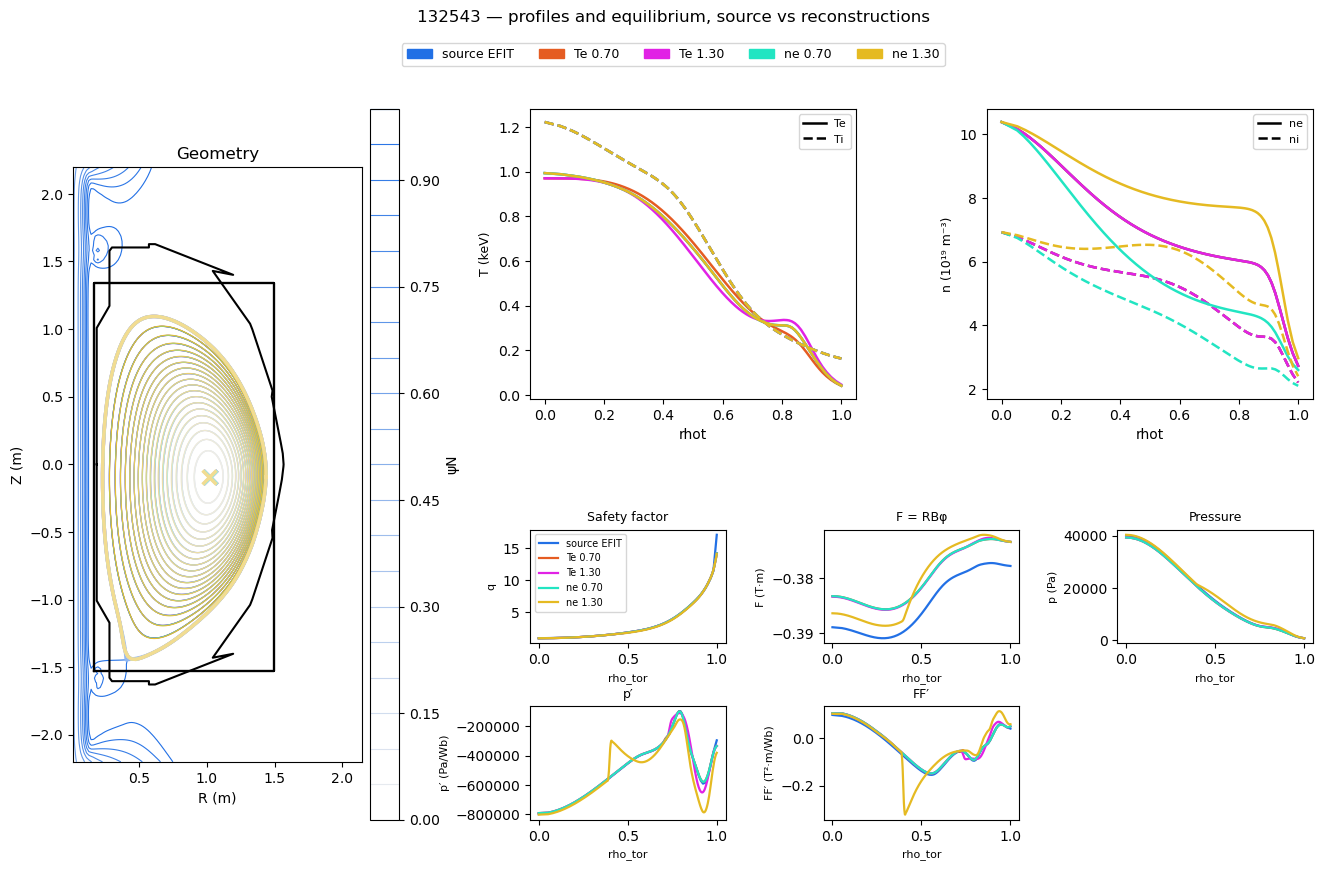

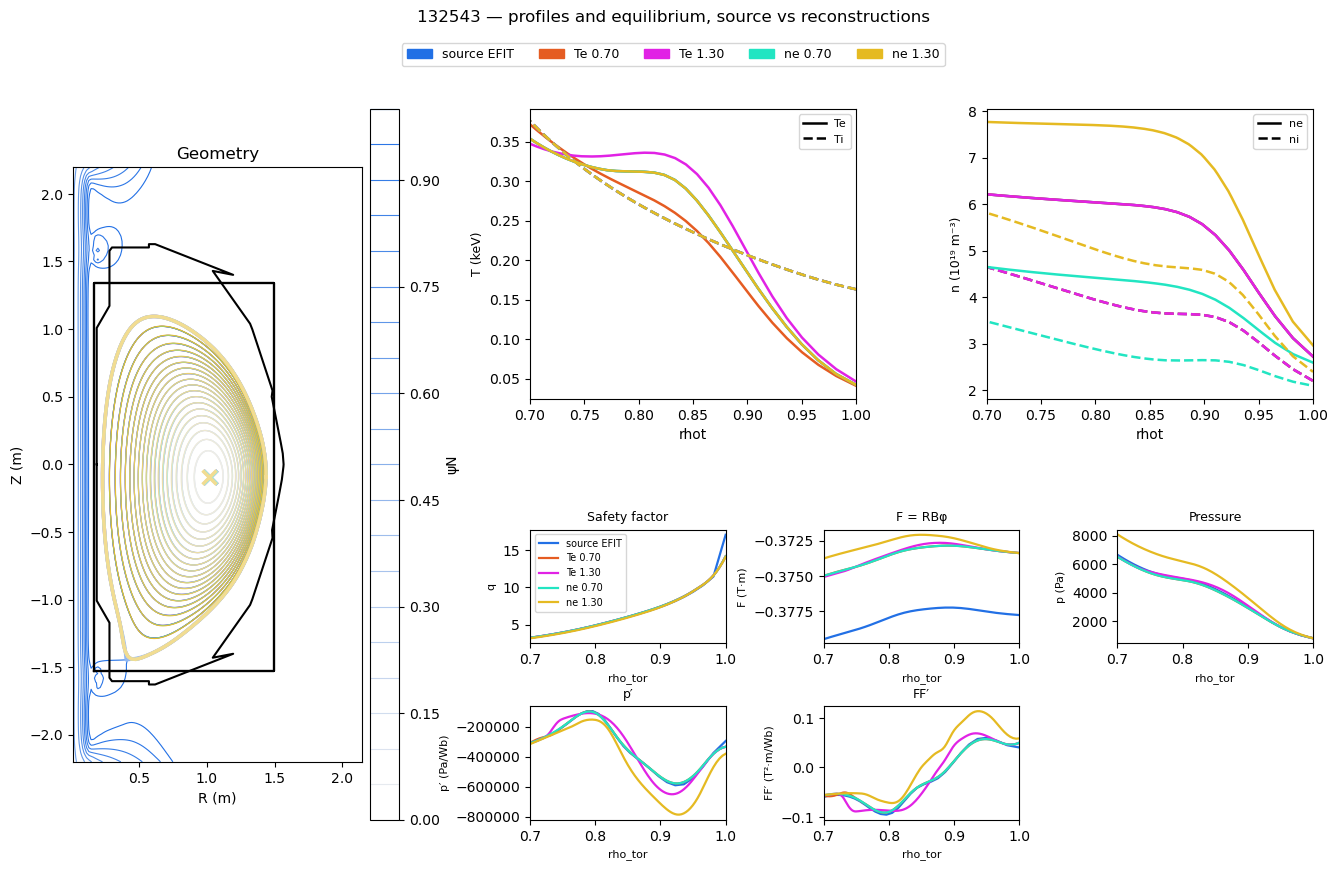

In [23]:
%matplotlib inline

if RUN[132543] and PLOT:
    print('displaying results for 132543')
    fig = compare(132543, ROWS[132543])
    fig = compare(132543, ROWS[132543], rhot=[0.7, 1.0])
    # print(fig)

## 132588

ELM-free, high triangularity. Its `ne` fit is pinned on the `b_pos` bound, so treat its `ne_ped_scale` rows as suspect until that is resolved.

In [5]:
if RUN[132588]:
    ROWS[132588], wd = rh.run_bounds(camp, 132588)
    display(rh.table(ROWS[132588], shot=132588))
else:
    print("132588 disabled — set RUN[132588] = True")

132588 disabled — set RUN[132588] = True


In [6]:
if RUN[132588] and PLOT:
    fig = compare(132588, ROWS[132588])

## 129015

ELMy, low triangularity.

In [7]:
if RUN[129015]:
    ROWS[129015], wd = rh.run_bounds(camp, 129015)
    display(rh.table(ROWS[129015], shot=129015))
else:
    print("129015 disabled — set RUN[129015] = True")

129015 disabled — set RUN[129015] = True


In [8]:
if RUN[129015] and PLOT:
    fig = compare(129015, ROWS[129015])

## 129038

ELM-free, low triangularity. Weakest fit of the four and a placeholder analysis radius, so its gate verdict carries less weight than the other three.

In [9]:
if RUN[129038]:
    ROWS[129038], wd = rh.run_bounds(camp, 129038)
    display(rh.table(ROWS[129038], shot=129038))
else:
    print("129038 disabled — set RUN[129038] = True")

129038 disabled — set RUN[129038] = True


In [10]:
if RUN[129038] and PLOT:
    fig = compare(129038, ROWS[129038])

## All solved discharges together

In [11]:
import pandas as pd
if ROWS:
    display(pd.DataFrame(
        [{"shot": s, "axis": r["axis"], "scale": r["scale"],
          "iters": r.get("iterations"), "accepted": r.get("accepted"),
          "dq_max": r.get("dq_max"), "wall_s": r.get("wall_s")}
         for s, rs in ROWS.items() for r in rs]
    ).pivot_table(index=["shot", "axis"], columns="scale", values="iters",
                  dropna=False))
else:
    print("nothing solved yet")

scale                0.7  1.3
shot   axis                  
132543 Te_ped_scale  2.0  2.0
       ne_ped_scale  2.0  2.0